In [ ]:
import numpy as np
import json
import pickle
import os
from collections import defaultdict
from pathlib import Path

np.random.seed(42)

CLUSTER_DIR = './mmseqs_ablation_source'
DATA_PATH = '../../data/hariboss_merged_5fd_with_decoys.pkl'
SAVE_DIR = './save_pkl'
N_FOLDS = 5

os.makedirs(SAVE_DIR, exist_ok=True)

# ============== Load clustering files ==============
cluster_files = sorted([f for f in os.listdir(CLUSTER_DIR) if f.endswith('.json')])
print(f"Found {len(cluster_files)} clustering files:")
for f in cluster_files:
    print(f"  {f}")

# ============== Load HARIBOSS data ==============
with open(DATA_PATH, 'rb') as f:
    data_original = pickle.load(f)

# Collect all complex keys in HARIBOSS
all_complex_keys = set()
for rna_key, rna_data in data_original.items():
    for complex_key in rna_data:
        all_complex_keys.add(complex_key)

print(f"\nHARIBOSS: {len(data_original)} RNA keys, {len(all_complex_keys)} complex keys")

Found 8 clustering files:
  cov01_clustered_seqid_0.3.json
  cov03_clustered_seqid_0.3.json
  cov05_clustered_seqid_0.3.json
  cov08_clustered_seqid_0.3.json
  cov08_clustered_seqid_0.7.json
  cov08_clustered_seqid_0.8.json
  cov08_clustered_seqid_0.9.json
  cov099_clustered_seqid_0.3.json

HARIBOSS: 862 RNA keys, 1246 complex keys


## 5-Fold Splitting Functions

Core logic:
1. Load MMseqs2 cluster JSON → extract cluster assignments  
2. Greedy assignment: sort clusters by size (descending), assign each to the smallest fold  
3. Update `train_split` in HARIBOSS data: sample in fold $i$ → `train_split[i] = False`, rest `True`  
4. Verify: no two samples from the same cluster appear in different folds

In [3]:
def normalize_key(key, hariboss_keys_set):
    """Normalize a cluster member key to match HARIBOSS complex key.
    
    Handles the trailing '_' vs '*' mismatch:
      cluster: '4e8k_A_QA_EPE_441_' -> HARIBOSS: '4e8k_A_QA_EPE_441*'
    """
    if key in hariboss_keys_set:
        return key
    # Try replacing trailing '_' with '*'
    if key.endswith('_'):
        alt = key[:-1] + '*'
        if alt in hariboss_keys_set:
            return alt
    return key  # return original if no match found


def load_clusters(json_path, hariboss_keys_set=None):
    """Load MMseqs2 cluster JSON and return cluster assignments.
    
    If hariboss_keys_set is provided, normalize member keys to match HARIBOSS.
    
    Returns:
        clusters: dict {cluster_id: [member_id, ...]}
        member_to_cluster: dict {member_id: cluster_id}
    """
    with open(json_path, 'r') as f:
        cluster_data = json.load(f)
    
    clusters = {}
    member_to_cluster = {}
    for cluster_rep, members in cluster_data.items():
        cluster_id = cluster_rep
        normalized_members = []
        for member_id in members:
            if hariboss_keys_set is not None:
                norm_id = normalize_key(member_id, hariboss_keys_set)
            else:
                norm_id = member_id
            normalized_members.append(norm_id)
            member_to_cluster[norm_id] = cluster_id
        clusters[cluster_id] = normalized_members
    
    return clusters, member_to_cluster


def greedy_fold_assignment(clusters, n_folds=5):
    """Assign clusters to folds using greedy balancing.
    
    Sort clusters by size (descending), assign each to the fold with fewest samples.
    
    Returns:
        fold_clusters: dict {fold_id: [cluster_id, ...]}
        sample_to_fold: dict {member_id: fold_id}
    """
    cluster_sizes = {cid: len(members) for cid, members in clusters.items()}
    sorted_clusters = sorted(cluster_sizes.keys(), key=lambda c: cluster_sizes[c], reverse=True)
    
    fold_clusters = {i: [] for i in range(n_folds)}
    fold_counts = {i: 0 for i in range(n_folds)}
    
    for cluster_id in sorted_clusters:
        min_fold = min(fold_counts, key=fold_counts.get)
        fold_clusters[min_fold].append(cluster_id)
        fold_counts[min_fold] += cluster_sizes[cluster_id]
    
    # Build sample -> fold mapping
    sample_to_fold = {}
    for fold_id, cids in fold_clusters.items():
        for cid in cids:
            for member in clusters[cid]:
                sample_to_fold[member] = fold_id
    
    return fold_clusters, sample_to_fold


def apply_split_to_hariboss(data_original, sample_to_fold, n_folds=5):
    """Apply fold assignment to HARIBOSS data.
    
    Uses shallow copy + new train_split list (avoids expensive deepcopy).
    
    Returns:
        data_split: modified copy of data_original with updated train_split
        stats: dict with matching statistics
    """
    data_split = {}
    matched, unmatched = 0, 0
    
    for rna_key, rna_data in data_original.items():
        new_rna_data = {}
        for complex_key, sample_data in rna_data.items():
            if complex_key in sample_to_fold:
                fold_id = sample_to_fold[complex_key]
                # Shallow copy: only replace train_split (no need to deepcopy large arrays)
                new_sample = dict(sample_data)
                new_sample['train_split'] = [i != fold_id for i in range(n_folds)]
                new_rna_data[complex_key] = new_sample
                matched += 1
            else:
                unmatched += 1
        if new_rna_data:
            data_split[rna_key] = new_rna_data
    
    return data_split, {'matched': matched, 'unmatched': unmatched}


def verify_no_leakage(data_split, clusters, sample_to_fold, n_folds=5):
    """Verify that no cluster has members in different folds."""
    violations = []
    
    for cluster_id, members in clusters.items():
        folds_seen = set()
        for member in members:
            if member in sample_to_fold:
                folds_seen.add(sample_to_fold[member])
        if len(folds_seen) > 1:
            violations.append({
                'cluster': cluster_id,
                'folds': sorted(folds_seen),
                'n_members': len(members)
            })
    
    return len(violations) == 0, violations


def get_fold_distribution(data_split, n_folds=5):
    """Get number of samples in each fold."""
    fold_dist = [0] * n_folds
    for rna_data in data_split.values():
        for sample in rna_data.values():
            test_fold = sample['train_split'].index(False)
            fold_dist[test_fold] += 1
    return fold_dist


print("Functions defined successfully (with key normalization, shallow copy).")

Functions defined successfully (with key normalization, shallow copy).


## Process All Clustering Variants

Run 5-fold split for each clustering file in `mmseqs_ablation_source/`.

In [4]:
# ============== Process all clustering variants ==============
results = {}  # store results for visualization

for cluster_file in cluster_files:
    print(f"\n{'='*80}")
    print(f"Processing: {cluster_file}")
    print(f"{'='*80}")
    
    name = cluster_file.replace('.json', '')
    
    # Load clusters (with key normalization to match HARIBOSS)
    json_path = os.path.join(CLUSTER_DIR, cluster_file)
    clusters, member_to_cluster = load_clusters(json_path, hariboss_keys_set=all_complex_keys)
    
    # Check coverage of HARIBOSS
    cluster_members = set(member_to_cluster.keys())
    coverage = len(cluster_members & all_complex_keys)
    print(f"  Clusters: {len(clusters)}")
    print(f"  Total members in clusters: {len(cluster_members)}")
    print(f"  Members matching HARIBOSS: {coverage}/{len(all_complex_keys)}")
    
    # Greedy fold assignment
    fold_clusters, sample_to_fold = greedy_fold_assignment(clusters, N_FOLDS)
    
    # Apply split
    data_split, stats = apply_split_to_hariboss(data_original, sample_to_fold, N_FOLDS)
    print(f"  Matched: {stats['matched']}, Unmatched: {stats['unmatched']}")
    
    # Verify no leakage
    passed, violations = verify_no_leakage(data_split, clusters, sample_to_fold, N_FOLDS)
    print(f"  Leakage test: {'PASSED' if passed else f'FAILED ({len(violations)} violations)'}")
    
    # Fold distribution
    fold_dist = get_fold_distribution(data_split, N_FOLDS)
    print(f"  Fold sizes: {fold_dist}")
    print(f"  Total: {sum(fold_dist)}, Std: {np.std(fold_dist):.2f}")
    
    # Save pkl
    output_name = f"hariboss_5fd_{name}.pkl"
    output_path = os.path.join(SAVE_DIR, output_name)
    with open(output_path, 'wb') as f:
        pickle.dump(data_split, f)
    print(f"  Saved: {output_path}")
    
    # Store results
    results[name] = {
        'clusters': clusters,
        'member_to_cluster': member_to_cluster,
        'sample_to_fold': sample_to_fold,
        'fold_clusters': fold_clusters,
        'data_split': data_split,
        'fold_dist': fold_dist,
        'n_clusters': len(clusters),
        'passed': passed,
        'stats': stats
    }

print(f"\n{'='*80}")
print(f"All {len(cluster_files)} clustering variants processed!")
print(f"Saved pkl files to: {SAVE_DIR}/")


Processing: cov01_clustered_seqid_0.3.json
  Clusters: 185
  Total members in clusters: 1246
  Members matching HARIBOSS: 1246/1246
  Matched: 1246, Unmatched: 0
  Leakage test: PASSED
  Fold sizes: [250, 249, 249, 249, 249]
  Total: 1246, Std: 0.40
  Saved: ./save_pkl/hariboss_5fd_cov01_clustered_seqid_0.3.pkl

Processing: cov03_clustered_seqid_0.3.json
  Clusters: 190
  Total members in clusters: 1246
  Members matching HARIBOSS: 1246/1246
  Matched: 1246, Unmatched: 0
  Leakage test: PASSED
  Fold sizes: [250, 249, 249, 249, 249]
  Total: 1246, Std: 0.40
  Saved: ./save_pkl/hariboss_5fd_cov03_clustered_seqid_0.3.pkl

Processing: cov05_clustered_seqid_0.3.json
  Clusters: 197
  Total members in clusters: 1246
  Members matching HARIBOSS: 1246/1246
  Matched: 1246, Unmatched: 0
  Leakage test: PASSED
  Fold sizes: [250, 249, 249, 249, 249]
  Total: 1246, Std: 0.40
  Saved: ./save_pkl/hariboss_5fd_cov05_clustered_seqid_0.3.pkl

Processing: cov08_clustered_seqid_0.3.json
  Clusters: 20

## Unit Tests

Verify the integrity of each split:
1. **No cluster leakage**: all members of every cluster are in the same fold  
2. **Complete coverage**: every HARIBOSS sample that appears in clusters is assigned  
3. **Valid train_split format**: each sample has exactly one `False` in `train_split`  
4. **Fold balance**: no fold deviates more than 20% from the target size  
5. **Reload test**: saved pkl can be loaded and matches in-memory data  
6. **Cross-fold sequence check**: verify same-cluster sequences don't leak across folds

In [5]:
# ============== Unit Tests ==============
import traceback

def run_unit_tests(name, res, data_original, cluster_dir, save_dir, n_folds=5):
    """Run all unit tests for a single split variant."""
    tests_passed = 0
    tests_failed = 0
    
    clusters = res['clusters']
    sample_to_fold = res['sample_to_fold']
    data_split = res['data_split']
    fold_dist = res['fold_dist']
    
    # ---- Test 1: No cluster leakage ----
    test_name = "No cluster leakage"
    try:
        for cluster_id, members in clusters.items():
            folds_in_cluster = set()
            for member in members:
                if member in sample_to_fold:
                    folds_in_cluster.add(sample_to_fold[member])
            assert len(folds_in_cluster) <= 1, \
                f"Cluster {cluster_id} has members in folds {folds_in_cluster}"
        tests_passed += 1
        print(f"  ✓ {test_name}")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    # ---- Test 2: Complete coverage ----
    test_name = "Complete coverage"
    try:
        # All clustered members that are in HARIBOSS should be in the split
        split_complex_keys = set()
        for rna_data in data_split.values():
            for ck in rna_data:
                split_complex_keys.add(ck)
        
        cluster_members_in_hariboss = set(sample_to_fold.keys()) & all_complex_keys
        missing = cluster_members_in_hariboss - split_complex_keys
        assert len(missing) == 0, \
            f"{len(missing)} samples in clusters+HARIBOSS but missing from split"
        tests_passed += 1
        print(f"  ✓ {test_name} ({len(split_complex_keys)} samples)")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    # ---- Test 3: Valid train_split format ----
    test_name = "Valid train_split format"
    try:
        for rna_key, rna_data in data_split.items():
            for ck, sample in rna_data.items():
                ts = sample['train_split']
                assert len(ts) == n_folds, \
                    f"{ck}: train_split length={len(ts)}, expected {n_folds}"
                assert ts.count(False) == 1, \
                    f"{ck}: train_split has {ts.count(False)} False values, expected 1"
                assert ts.count(True) == n_folds - 1, \
                    f"{ck}: train_split has {ts.count(True)} True values, expected {n_folds-1}"
        tests_passed += 1
        print(f"  ✓ {test_name}")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    # ---- Test 4: Fold balance ----
    test_name = "Fold balance (<20% deviation)"
    try:
        total = sum(fold_dist)
        target = total / n_folds
        for i, count in enumerate(fold_dist):
            deviation = abs(count - target) / target
            assert deviation < 0.20, \
                f"Fold {i} has {count} samples ({deviation:.1%} deviation from target {target:.0f})"
        tests_passed += 1
        print(f"  ✓ {test_name} (target={target:.0f}, actual={fold_dist})")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    # ---- Test 5: Reload test ----
    test_name = "Reload saved pkl"
    try:
        output_name = f"hariboss_5fd_{name}.pkl"
        output_path = os.path.join(save_dir, output_name)
        with open(output_path, 'rb') as f:
            data_reloaded = pickle.load(f)
        
        # Check same number of RNA keys and complex keys
        assert len(data_reloaded) == len(data_split), \
            f"Reloaded has {len(data_reloaded)} RNA keys vs {len(data_split)}"
        
        reloaded_total = sum(len(v) for v in data_reloaded.values())
        split_total = sum(len(v) for v in data_split.values())
        assert reloaded_total == split_total, \
            f"Reloaded has {reloaded_total} samples vs {split_total}"
        
        # Spot-check: verify train_split matches for a few samples
        checked = 0
        for rna_key in list(data_split.keys())[:10]:
            for ck in data_split[rna_key]:
                assert data_reloaded[rna_key][ck]['train_split'] == data_split[rna_key][ck]['train_split'], \
                    f"train_split mismatch for {ck}"
                checked += 1
        
        tests_passed += 1
        print(f"  ✓ {test_name} (checked {checked} samples)")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    # ---- Test 6: Cross-fold sequence check ----
    test_name = "No same-cluster sequences across folds"
    try:
        # Load the original cluster JSON to get sequences
        json_path = os.path.join(cluster_dir, f"{name}.json")
        with open(json_path, 'r') as f:
            cluster_data = json.load(f)
        
        for cluster_rep, members in cluster_data.items():
            member_folds = set()
            for member_id in members:
                if member_id in sample_to_fold:
                    member_folds.add(sample_to_fold[member_id])
            assert len(member_folds) <= 1, \
                f"Cluster {cluster_rep}: sequences in folds {member_folds}"
        
        tests_passed += 1
        print(f"  ✓ {test_name}")
    except Exception as e:
        tests_failed += 1
        print(f"  ✗ {test_name}: {e}")
    
    return tests_passed, tests_failed


# ============== Run all tests ==============
print("=" * 80)
print("UNIT TESTS")
print("=" * 80)

total_passed = 0
total_failed = 0

for name, res in results.items():
    print(f"\n--- {name} ---")
    p, f = run_unit_tests(name, res, data_original, CLUSTER_DIR, SAVE_DIR, N_FOLDS)
    total_passed += p
    total_failed += f

print(f"\n{'='*80}")
print(f"TOTAL: {total_passed} passed, {total_failed} failed out of {total_passed + total_failed} tests")
if total_failed == 0:
    print("ALL TESTS PASSED!")
else:
    print(f"WARNING: {total_failed} tests FAILED!")

UNIT TESTS

--- cov01_clustered_seqid_0.3 ---
  ✓ No cluster leakage
  ✓ Complete coverage (1246 samples)
  ✓ Valid train_split format
  ✓ Fold balance (<20% deviation) (target=249, actual=[250, 249, 249, 249, 249])
  ✓ Reload saved pkl (checked 10 samples)
  ✓ No same-cluster sequences across folds

--- cov03_clustered_seqid_0.3 ---
  ✓ No cluster leakage
  ✓ Complete coverage (1246 samples)
  ✓ Valid train_split format
  ✓ Fold balance (<20% deviation) (target=249, actual=[250, 249, 249, 249, 249])
  ✓ Reload saved pkl (checked 10 samples)
  ✓ No same-cluster sequences across folds

--- cov05_clustered_seqid_0.3 ---
  ✓ No cluster leakage
  ✓ Complete coverage (1246 samples)
  ✓ Valid train_split format
  ✓ Fold balance (<20% deviation) (target=249, actual=[250, 249, 249, 249, 249])
  ✓ Reload saved pkl (checked 10 samples)
  ✓ No same-cluster sequences across folds

--- cov08_clustered_seqid_0.3 ---
  ✓ No cluster leakage
  ✓ Complete coverage (1246 samples)
  ✓ Valid train_split fo

## Visualization

1. **Fold distribution** bar chart for each clustering variant  
2. **Cluster size distribution** histograms  
3. **Summary comparison** table across all variants

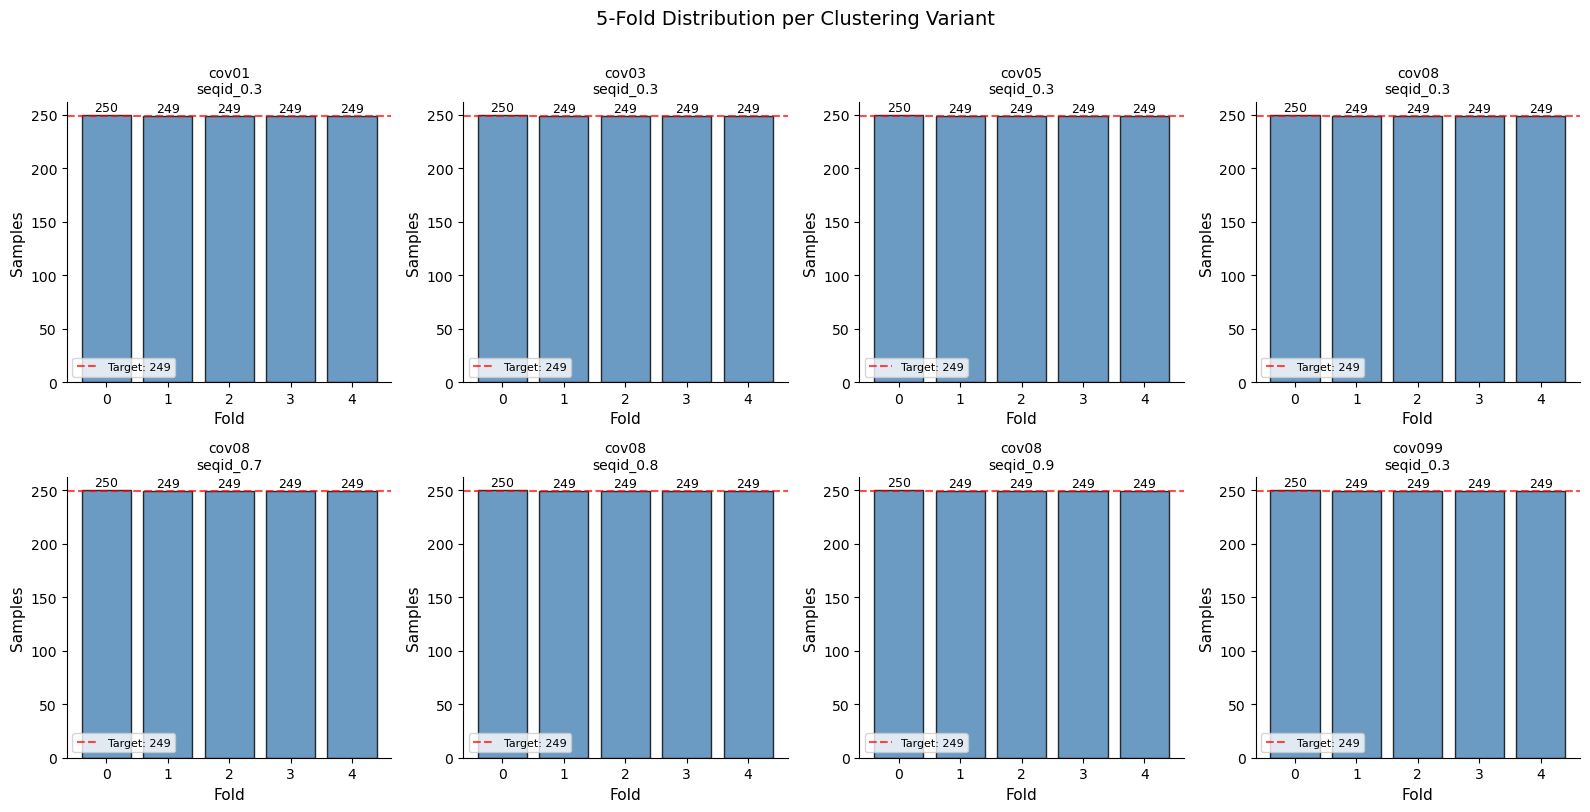

Saved: fold_distributions.png


In [6]:
import matplotlib.pyplot as plt

# ============== 1. Fold Distribution for Each Variant ==============
n_variants = len(results)
n_cols = min(4, n_variants)
n_rows = (n_variants + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_variants == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (name, res) in enumerate(sorted(results.items())):
    ax = axes[idx]
    fold_dist = res['fold_dist']
    total = sum(fold_dist)
    target = total / N_FOLDS
    
    bars = ax.bar(range(N_FOLDS), fold_dist, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(y=target, color='red', linestyle='--', alpha=0.7, label=f'Target: {target:.0f}')
    
    # Annotate bar values
    for bar, val in zip(bars, fold_dist):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Samples', fontsize=11)
    ax.set_title(name.replace('_clustered_', '\n'), fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide empty axes
for idx in range(n_variants, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('5-Fold Distribution per Clustering Variant', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fold_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fold_distributions.png")

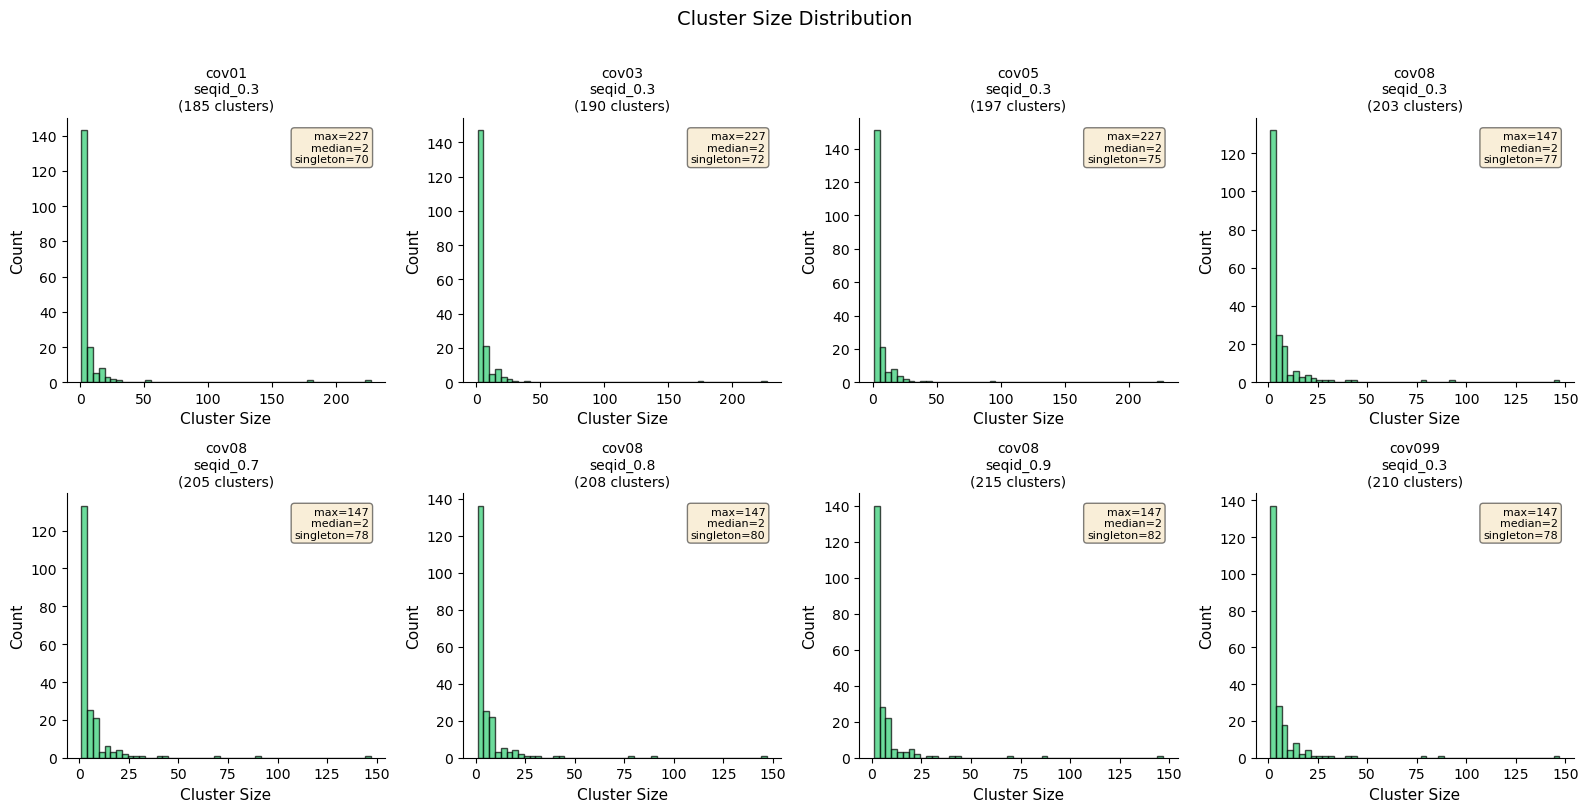

Saved: cluster_size_distributions.png


In [7]:
# ============== 2. Cluster Size Distribution ==============
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_variants == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (name, res) in enumerate(sorted(results.items())):
    ax = axes[idx]
    clusters = res['clusters']
    sizes = [len(members) for members in clusters.values()]
    
    ax.hist(sizes, bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
    ax.set_xlabel('Cluster Size', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f"{name.replace('_clustered_', chr(10))}\n({len(clusters)} clusters)", fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add stats text
    ax.text(0.95, 0.95, f"max={max(sizes)}\nmedian={np.median(sizes):.0f}\nsingleton={sizes.count(1)}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for idx in range(n_variants, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Cluster Size Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cluster_size_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: cluster_size_distributions.png")

In [8]:
# ============== 3. Summary Comparison Table ==============
import pandas as pd

summary_rows = []
for name in sorted(results.keys()):
    res = results[name]
    fd = res['fold_dist']
    clusters = res['clusters']
    sizes = [len(m) for m in clusters.values()]
    
    summary_rows.append({
        'Variant': name,
        'Clusters': len(clusters),
        'Total Samples': sum(fd),
        'Matched': res['stats']['matched'],
        'Unmatched': res['stats']['unmatched'],
        'Fold Sizes': str(fd),
        'Fold Std': f"{np.std(fd):.2f}",
        'Max Cluster': max(sizes),
        'Median Cluster': f"{np.median(sizes):.0f}",
        'Singletons': sizes.count(1),
        'Leakage Test': '✓' if res['passed'] else '✗'
    })

summary_df = pd.DataFrame(summary_rows)
print("Summary of all clustering variants:\n")
display(summary_df)

Summary of all clustering variants:



,Variant,Clusters,Total Samples,Matched,Unmatched,Fold Sizes,Fold Std,Max Cluster,Median Cluster,Singletons,Leakage Test
0,cov01_clustered_seqid_0.3,185,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,227,2,70,✓
1,cov03_clustered_seqid_0.3,190,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,227,2,72,✓
2,cov05_clustered_seqid_0.3,197,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,227,2,75,✓
3,cov08_clustered_seqid_0.3,203,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,147,2,77,✓
4,cov08_clustered_seqid_0.7,205,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,147,2,78,✓
5,cov08_clustered_seqid_0.8,208,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,147,2,80,✓
6,cov08_clustered_seqid_0.9,215,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,147,2,82,✓
7,cov099_clustered_seqid_0.3,210,1246,1246,0,"[250, 249, 249, 249, 249]",0.40,147,2,78,✓


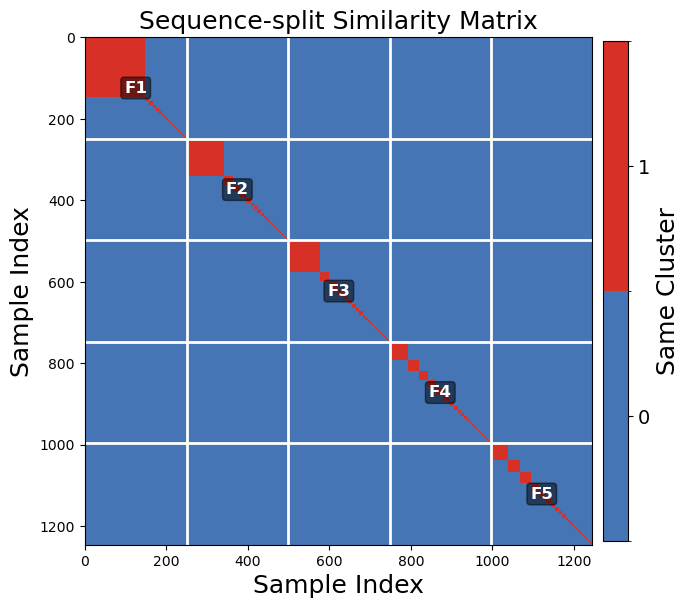

Saved: membership_matrix_cov08_clustered_seqid_0.3.png
Matrix size: 1246x1246 (1246 samples in 203 clusters)


In [9]:
# ============== 4. Cluster Membership Matrix (block-diagonal by fold) ==============
# Similar to chain_split.ipynb's RMscore matrix heatmap
# Show one representative variant: cov08_clustered_seqid_0.3
import matplotlib.colors as mcolors

demo_name = 'cov08_clustered_seqid_0.3'
if demo_name not in results:
    demo_name = list(results.keys())[0]

res = results[demo_name]
clusters = res['clusters']
sample_to_fold = res['sample_to_fold']
fold_clusters_map = res['fold_clusters']

# Build ordered list of samples: grouped by fold, then by cluster
ordered_samples = []
ordered_folds = []
for fold_id in range(N_FOLDS):
    for cluster_id in fold_clusters_map[fold_id]:
        for member in clusters[cluster_id]:
            if member in sample_to_fold:
                ordered_samples.append(member)
                ordered_folds.append(fold_id)

n_samples = len(ordered_samples)
sample_to_idx = {s: i for i, s in enumerate(ordered_samples)}

# Build same-cluster membership matrix (binary: 1 if same cluster, 0 otherwise)
member_to_cluster = res['member_to_cluster']
# For efficiency, build cluster -> indices mapping
cluster_to_indices = defaultdict(list)
for i, sample in enumerate(ordered_samples):
    cid = member_to_cluster[sample]
    cluster_to_indices[cid].append(i)

# Create sparse-ish matrix
membership_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)
for cid, indices in cluster_to_indices.items():
    for i in indices:
        for j in indices:
            membership_matrix[i, j] = 1.0

# Find fold boundaries
fold_boundaries = []
for f in range(N_FOLDS):
    indices = [i for i, fold in enumerate(ordered_folds) if fold == f]
    if indices:
        fold_boundaries.append((min(indices), max(indices)))

# Plot with binary colormap
cmap_binary = mcolors.ListedColormap(['#4575b4', '#d73027'])
bounds = [-0.5, 0.5, 1.5]
norm_binary = mcolors.BoundaryNorm(bounds, cmap_binary.N)

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(membership_matrix, cmap=cmap_binary, norm=norm_binary, aspect='equal', interpolation='nearest')
ax.set_title(f'Sequence-split Similarity Matrix', fontsize=18)
ax.set_xlabel('Sample Index', fontsize=18)
ax.set_ylabel('Sample Index', fontsize=18)
cbar = fig.colorbar(im, ax=ax, shrink=1.0, pad=0.02, fraction=0.046, ticks=[0, 1])
cbar.set_label('Same Cluster', fontsize=18)
cbar.ax.set_yticklabels(['0', '1'], fontsize=14)

# Draw fold boundary lines and labels on diagonal blocks
for f, (start, end) in enumerate(fold_boundaries):
    if f > 0:
        ax.axhline(y=start - 0.5, color='white', linewidth=2)
        ax.axvline(x=start - 0.5, color='white', linewidth=2)
    mid = (start + end) / 2
    ax.text(mid, mid, f'F{f+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f'membership_matrix_{demo_name}.png'), dpi=600, bbox_inches='tight')
plt.show()
print(f"Saved: membership_matrix_{demo_name}.png")
print(f"Matrix size: {n_samples}x{n_samples} ({n_samples} samples in {len(clusters)} clusters)")

In [10]:
# ============== Unit Test: Same-cluster RNA sequences only in one fold ==============
# For each clustering variant, load the cluster JSON (which contains actual sequences),
# then check that every sequence appearing in a cluster maps to exactly one fold.

print("=" * 90)
print("TEST: All RNA sequences within the same cluster appear in exactly one fold")
print("=" * 90)

all_passed = True

for name, res in results.items():
    sample_to_fold = res['sample_to_fold']
    data_split = res['data_split']
    
    # Build: complex_key -> rna_chain_sequence from the split data
    key_to_seq = {}
    for rna_key, rna_data in data_split.items():
        for ck, sample in rna_data.items():
            key_to_seq[ck] = sample.get('rna_chain_sequence', None)
    
    # Load original cluster JSON to get cluster membership
    json_path = os.path.join(CLUSTER_DIR, f"{name}.json")
    with open(json_path, 'r') as f:
        cluster_data = json.load(f)
    
    violations = []
    for cluster_rep, members in cluster_data.items():
        # Collect (sequence, fold) pairs for members in this cluster
        seq_fold_pairs = []
        for member_id in members:
            norm_id = normalize_key(member_id, all_complex_keys)
            if norm_id in sample_to_fold:
                fold = sample_to_fold[norm_id]
                seq = key_to_seq.get(norm_id, members[member_id].get('sequence', ''))
                seq_fold_pairs.append((norm_id, seq, fold))
        
        if not seq_fold_pairs:
            continue
        
        # Check 1: all members in same fold
        folds_in_cluster = set(f for _, _, f in seq_fold_pairs)
        if len(folds_in_cluster) > 1:
            violations.append(f"  Cluster {cluster_rep}: members in folds {folds_in_cluster}")
        
        # Check 2: identical sequences within the cluster should be in same fold
        seq_to_folds = defaultdict(set)
        for mid, seq, fold in seq_fold_pairs:
            seq_to_folds[seq].add(fold)
        for seq, folds in seq_to_folds.items():
            if len(folds) > 1:
                violations.append(
                    f"  Cluster {cluster_rep}: identical seq (len={len(seq)}) in folds {folds}"
                )
    
    status = "PASSED" if len(violations) == 0 else "FAILED"
    if violations:
        all_passed = False
    print(f"\n{name}: {status} ({len(violations)} violations)")
    for v in violations[:5]:
        print(v)
    if len(violations) > 5:
        print(f"  ... and {len(violations) - 5} more")

print(f"\n{'=' * 90}")
print(f"Overall: {'ALL PASSED' if all_passed else 'SOME FAILED'}")

TEST: All RNA sequences within the same cluster appear in exactly one fold

cov01_clustered_seqid_0.3: PASSED (0 violations)

cov03_clustered_seqid_0.3: PASSED (0 violations)

cov05_clustered_seqid_0.3: PASSED (0 violations)

cov08_clustered_seqid_0.3: PASSED (0 violations)

cov08_clustered_seqid_0.7: PASSED (0 violations)

cov08_clustered_seqid_0.8: PASSED (0 violations)

cov08_clustered_seqid_0.9: PASSED (0 violations)

cov099_clustered_seqid_0.3: PASSED (0 violations)

Overall: ALL PASSED
